# Contributors

- Anees Umer - 16266362 
- Denzel Wilson Thoppil - 14665728 
- Shibli, Ahmad Raza - 28751254

# Exercise 4.1: 
Evolution of age distribution.

In [10]:
%pip install numpy
%pip install pandas
%pip install matplot
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Saved → c:\Users\Umer\Documents\UniGOttingen\Visualization\Visualization\Problem4Submission\fig1_pyramids.png
Saved → c:\Users\Umer\Documents\UniGOttingen\Visualization\Visualization\Problem4Submission\fig2_heatmaps.png


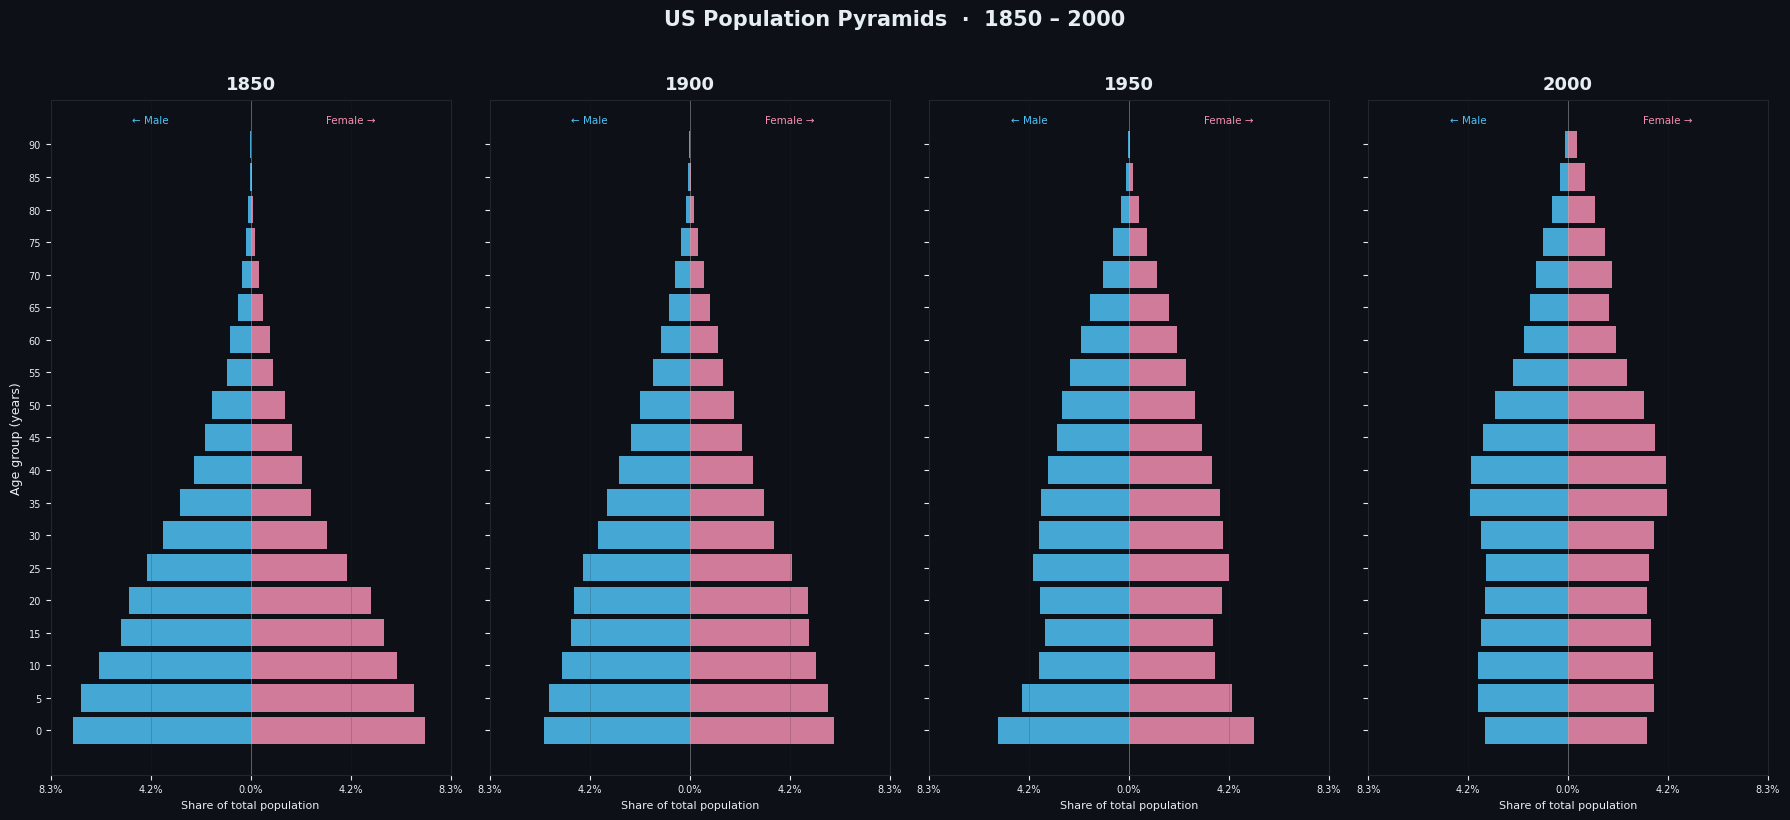

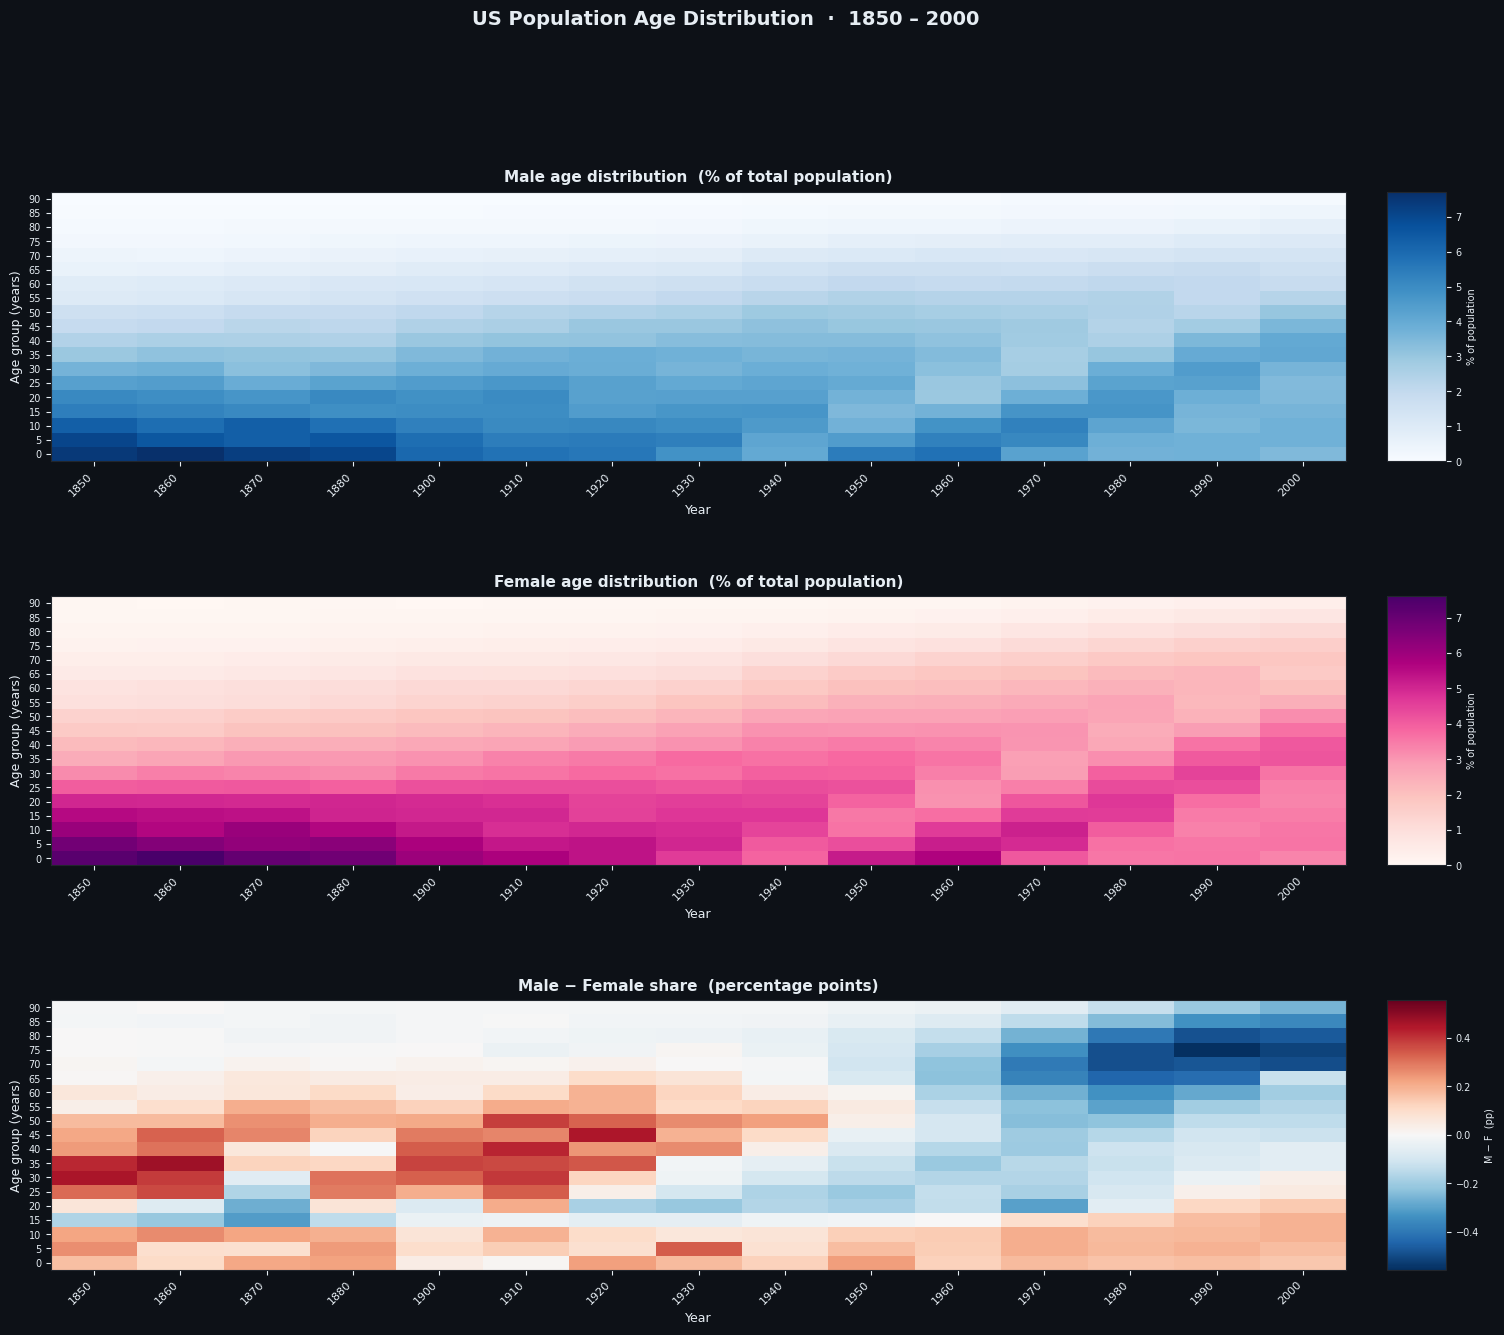

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path


HERE = Path.cwd()
CSV  = HERE / "population_us.csv"
OUT1 = HERE / "fig1_pyramids.png"
OUT2 = HERE / "fig2_heatmaps.png"


df = pd.read_csv(CSV)
df["sex_label"] = df["sex"].map({1: "Male", 2: "Female"})

years = sorted(df["year"].unique())   
ages  = sorted(df["age"].unique())    

df["share"] = df["people"] / df.groupby("year")["people"].transform("sum") * 100

MALE_COL   = "#4FC3F7"
FEMALE_COL = "#F48FB1"
BG         = "#0d1117"
TEXT       = "#e6edf3"
GRID       = "#21262d"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor":   GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color":  TEXT, "grid.color":   GRID,
    "font.family": "DejaVu Sans",
})


selected = [1850, 1900, 1950, 2000]
fig1, axes = plt.subplots(1, 4, figsize=(18, 8), sharey=True)
fig1.suptitle("US Population Pyramids  ·  1850 – 2000",
              fontsize=15, fontweight="bold", color=TEXT, y=1.02)

max_share = df["share"].max() * 1.08

for ax, yr in zip(axes, selected):
    sub = df[df["year"] == yr]
    m = sub[sub["sex"] == 1].set_index("age")["share"].reindex(ages, fill_value=0)
    f = sub[sub["sex"] == 2].set_index("age")["share"].reindex(ages, fill_value=0)

    ax.barh(ages, -m.values, height=4.2, color=MALE_COL,   alpha=0.85, label="Male")
    ax.barh(ages,  f.values, height=4.2, color=FEMALE_COL, alpha=0.85, label="Female")

    ax.set_xlim(-max_share, max_share)
    ax.set_title(str(yr), fontsize=13, fontweight="bold", color=TEXT, pad=8)
    ax.axvline(0, color=TEXT, linewidth=0.7, alpha=0.35)
    ax.grid(axis="x", linewidth=0.4, alpha=0.35)

  
    tick_vals = np.linspace(-max_share, max_share, 5)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f"{abs(v):.1f}%" for v in tick_vals], fontsize=7)
    ax.set_xlabel("Share of total population", fontsize=8)

    if ax is axes[0]:
        ax.set_yticks(ages)
        ax.set_yticklabels([str(a) for a in ages], fontsize=7)
        ax.set_ylabel("Age group (years)", fontsize=9)

    ax.text(-max_share * 0.5, 93, "← Male",
            ha="center", va="bottom", fontsize=7.5, color=MALE_COL)
    ax.text( max_share * 0.5, 93, "Female →",
            ha="center", va="bottom", fontsize=7.5, color=FEMALE_COL)

fig1.tight_layout()
fig1.savefig(OUT1, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Saved → {OUT1}")


def pivot(sex_val):
    return (df[df["sex"] == sex_val]
            .pivot_table(index="age", columns="year", values="share")
            .reindex(index=ages, columns=years))

M_mat = pivot(1)
F_mat = pivot(2)
D_mat = M_mat - F_mat  

fig2 = plt.figure(figsize=(18, 14))
fig2.patch.set_facecolor(BG)
gs = gridspec.GridSpec(3, 2, width_ratios=[22, 1], hspace=0.5, wspace=0.06)

panels = [
    (M_mat, "Male age distribution  (% of total population)",   "Blues",  False),
    (F_mat, "Female age distribution  (% of total population)", "RdPu",   False),
    (D_mat, "Male − Female share  (percentage points)",          "RdBu_r", True),
]

for row, (mat, title, cmap, diverging) in enumerate(panels):
    ax  = fig2.add_subplot(gs[row, 0])
    cax = fig2.add_subplot(gs[row, 1])

    if diverging:
        absmax = np.nanmax(np.abs(mat.values))
        norm = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
        im = ax.imshow(mat.values, aspect="auto", cmap=cmap,
                       origin="lower", norm=norm)
    else:
        im = ax.imshow(mat.values, aspect="auto", cmap=cmap,
                       origin="lower", vmin=0, vmax=mat.values.max())

    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ages)))
    ax.set_yticklabels(ages, fontsize=7)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("Age group (years)", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold", color=TEXT, pad=7)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

    cb = fig2.colorbar(im, cax=cax)
    cb.ax.yaxis.set_tick_params(color=TEXT, labelsize=7)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT)
    cb.set_label("M − F  (pp)" if diverging else "% of population",
                 fontsize=7, color=TEXT)

fig2.suptitle("US Population Age Distribution  ·  1850 – 2000",
              fontsize=14, fontweight="bold", color=TEXT, y=1.01)

fig2.savefig(OUT2, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Saved → {OUT2}")

# Exercise 4.2: 
Central limit theorem

Saved -> c:\Users\Umer\Documents\UniGOttingen\Visualization\Visualization\Problem4Submission\fig_clt.png


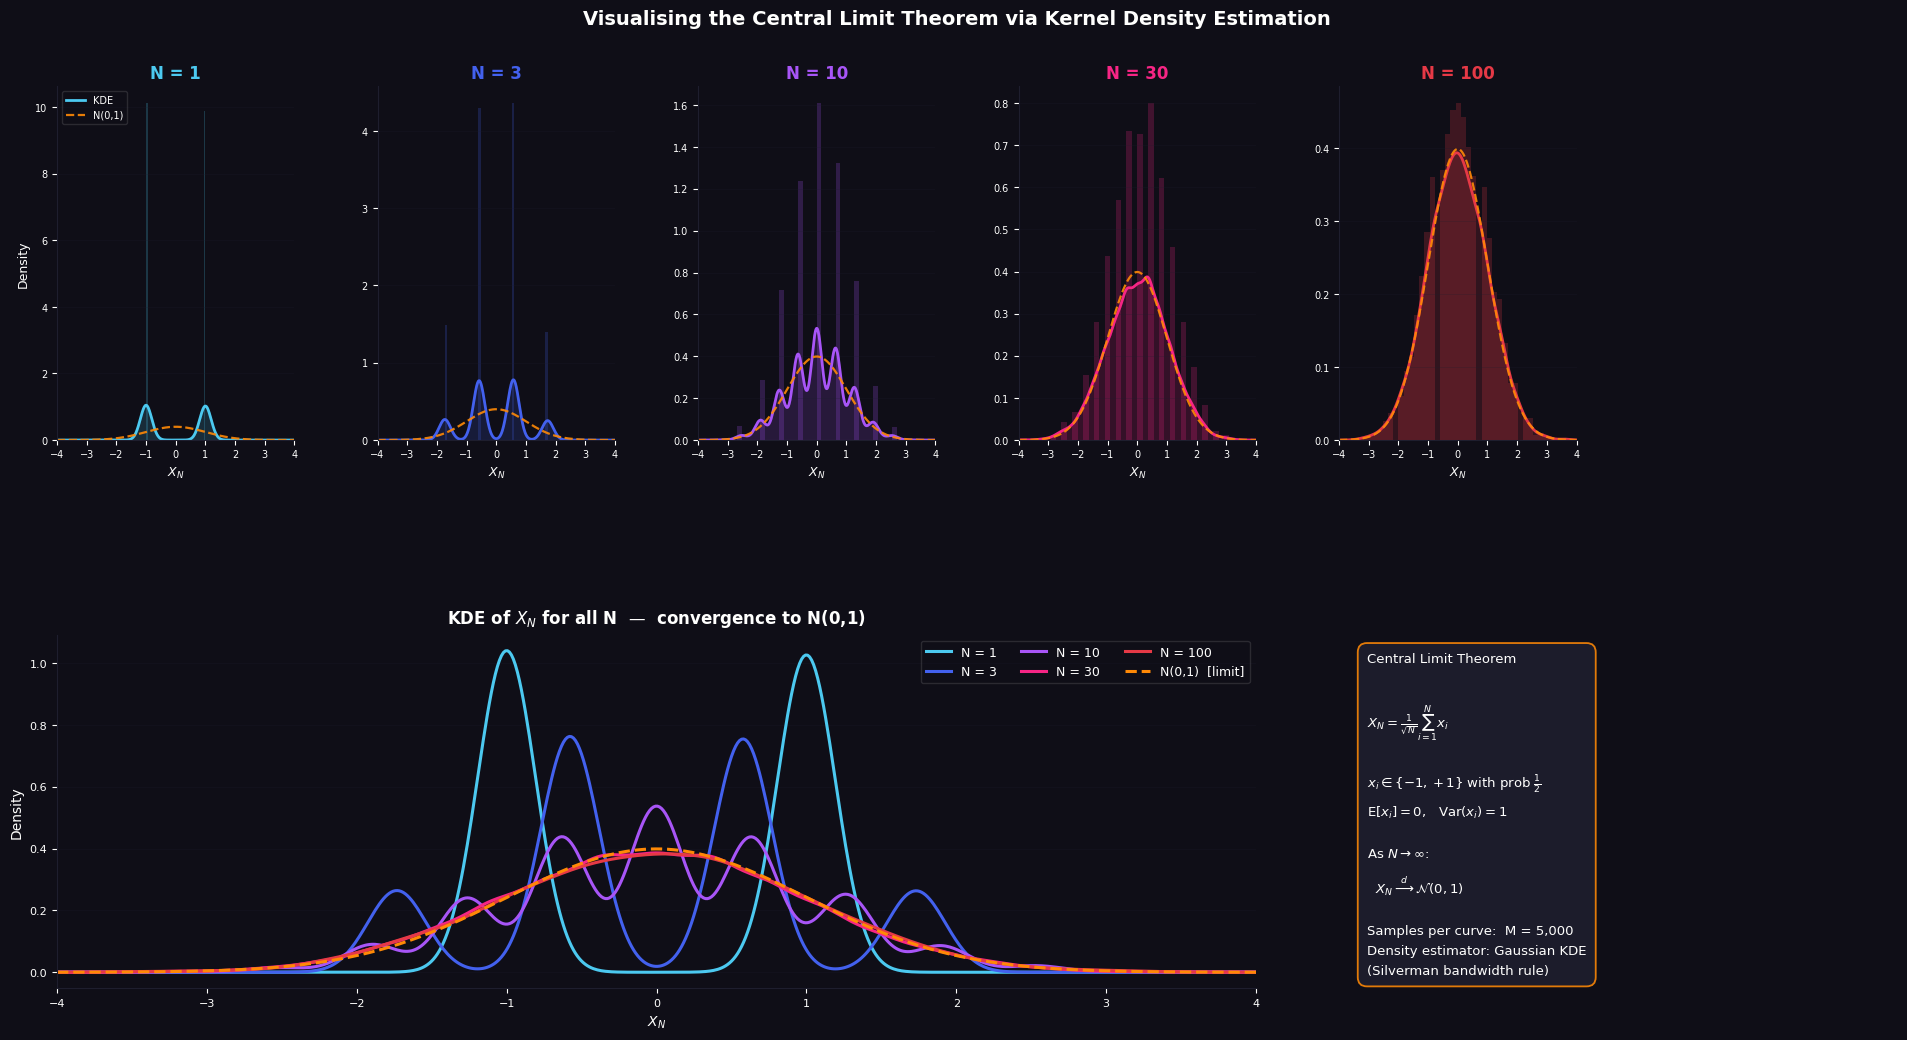

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from pathlib import Path

rng = np.random.default_rng(seed=42)

def sample_XN(M: int, N: int, rng=rng) -> np.ndarray:
    xi = rng.choice([-1, 1], size=(M, N))  
    return xi.sum(axis=1) / np.sqrt(N)     

M  = 5000
Ns = [1, 3, 10, 30, 100]

BG      = "#0f0e17"
TEXT    = "#fffffe"
GRID    = "#1e1e2e"
NORMAL  = "#ff8906"
COLORS  = ["#4cc9f0", "#4361ee", "#a855f7", "#f72585", "#e63946"]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": GRID,
    "font.family": "DejaVu Sans",
})

fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 6, figure=fig,
                       hspace=0.55, wspace=0.35,
                       left=0.05, right=0.97, top=0.90, bottom=0.08)

x_grid     = np.linspace(-4, 4, 600)
normal_pdf = norm.pdf(x_grid)


def gaussian_kde(samples, x_grid):
    n = len(samples)
    h = 1.06 * samples.std(ddof=1) * n**(-1/5)
    kde = np.mean(norm.pdf((x_grid[:, None] - samples[None, :]) / h), axis=1) / h
    return kde


for k, (N, col) in enumerate(zip(Ns, COLORS)):
    ax = fig.add_subplot(gs[0, k])
    samples = sample_XN(M, N)
    kde     = gaussian_kde(samples, x_grid)

    ax.hist(samples, bins=40, density=True, color=col, alpha=0.22, linewidth=0)
    ax.fill_between(x_grid, kde, alpha=0.16, color=col)
    ax.plot(x_grid, kde, color=col, linewidth=2.0, label="KDE")
    ax.plot(x_grid, normal_pdf, color=NORMAL, linewidth=1.6,
            linestyle="--", alpha=0.9, label="N(0,1)")

    ax.set_xlim(-4, 4)
    ax.set_ylim(bottom=0)
    ax.set_title(f"N = {N}", fontsize=12, fontweight="bold", color=col, pad=6)
    ax.set_xlabel("$X_N$", fontsize=9)
    if k == 0:
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, framealpha=0.15, loc="upper left")
    ax.tick_params(labelsize=7)
    ax.grid(axis="y", linewidth=0.4, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)


ax_all = fig.add_subplot(gs[1, :4])
for N, col in zip(Ns, COLORS):
    samples = sample_XN(M, N)
    kde = gaussian_kde(samples, x_grid)
    ax_all.plot(x_grid, kde, color=col, linewidth=2.2, label=f"N = {N}")

ax_all.plot(x_grid, normal_pdf, color=NORMAL, linewidth=2.2,
            linestyle="--", label="N(0,1)  [limit]")
ax_all.set_xlim(-4, 4)
ax_all.set_xlabel("$X_N$", fontsize=10)
ax_all.set_ylabel("Density", fontsize=10)
ax_all.set_title("KDE of $X_N$ for all N  —  convergence to N(0,1)",
                 fontsize=12, fontweight="bold", color=TEXT, pad=8)
ax_all.legend(fontsize=9, framealpha=0.15, ncol=3)
ax_all.grid(axis="y", linewidth=0.4, alpha=0.4)
ax_all.spines[["top", "right"]].set_visible(False)
ax_all.tick_params(labelsize=8)


ax_txt = fig.add_subplot(gs[1, 4:])
ax_txt.axis("off")


lines = [
    "Central Limit Theorem",
    "",
    r"$X_N = \frac{1}{\sqrt{N}}\sum_{i=1}^{N} x_i$",
    "",
    r"$x_i \in \{-1,+1\}$ with prob $\frac{1}{2}$",
    r"$\mathrm{E}[x_i]=0$,   $\mathrm{Var}(x_i)=1$",
    "",
    "As $N \\to \\infty$:",
    r"  $X_N \overset{d}{\longrightarrow} \mathcal{N}(0,1)$",
    "",
    f"Samples per curve:  M = {M:,}",
    "Density estimator: Gaussian KDE",
    "(Silverman bandwidth rule)",
]
note = "\n".join(lines)

ax_txt.text(0.05, 0.95, note, transform=ax_txt.transAxes,
            fontsize=9.5, va="top", ha="left", color=TEXT, linespacing=1.7,
            bbox=dict(boxstyle="round,pad=0.7", facecolor="#1e1e2e",
                      edgecolor=NORMAL, linewidth=1.3, alpha=0.88))

fig.suptitle(
    "Visualising the Central Limit Theorem via Kernel Density Estimation",
    fontsize=14, fontweight="bold", color=TEXT, y=0.97)

OUT = Path.cwd() / "fig_clt.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Saved -> {OUT}")